# **Capstone project: Providing data-driven suggestions for HR**

## Description and deliverables

This capstone project is an opportunity for you to analyze a dataset and build predictive models that can provide insights to the Human Resources (HR) department of a large consulting firm.

Upon completion, you will have two artifacts that you will be able to present to future employers. One is a brief one-page summary of this project that you will present to external stakeholders as the data professional in Salifort Motors. The other is a complete code notebook provided here. Based on your prior coursework, select one method to complete this project: use either a regression model or a machine learning model to predict whether an employee will leave the company. The exemplar following this actiivty shows both approaches, but you only need to do one.

In your deliverables, you will include the model evaluation (and interpretation if applicable), a data visualization(s) of your choice that is directly related to the question you ask, ethical considerations, and the resources you used to troubleshoot and find answers or solutions.


# **PACE stages**


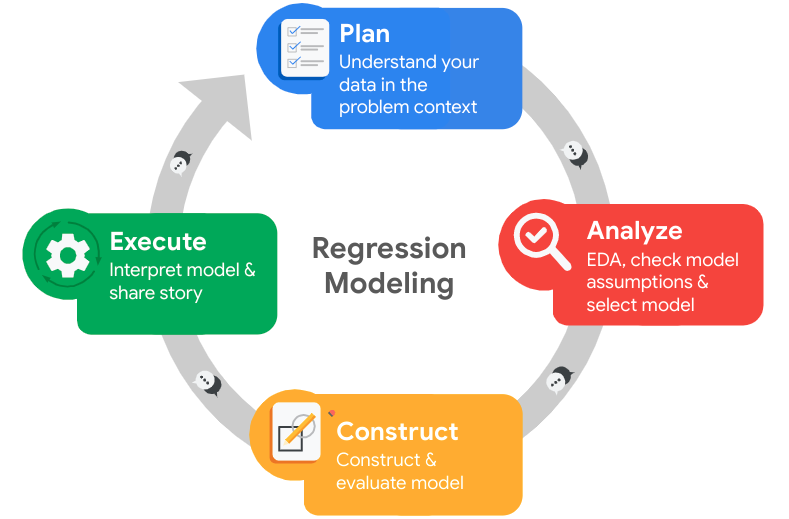

## **Pace: Plan**

Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

In this stage, consider the following:

### Understand the business scenario and problem

The HR department at Salifort Motors wants to take some initiatives to improve employee satisfaction levels at the company. They collected data from employees, but now they don’t know what to do with it. They refer to you as a data analytics professional and ask you to provide data-driven suggestions based on your understanding of the data. They have the following question: what’s likely to make the employee leave the company?

Your goals in this project are to analyze the data collected by the HR department and to build a model that predicts whether or not an employee will leave the company.

If you can predict employees likely to quit, it might be possible to identify factors that contribute to their leaving. Because it is time-consuming and expensive to find, interview, and hire new employees, increasing employee retention will be beneficial to the company.

### Familiarize yourself with the HR dataset

The dataset that you'll be using in this lab contains 15,000 rows and 10 columns for the variables listed below. 

**Note:** you don't need to download any data to complete this lab. For more information about the data, refer to its source on [Kaggle](https://www.kaggle.com/datasets/mfaisalqureshi/hr-analytics-and-job-prediction?select=HR_comma_sep.csv).

Variable  |Description |
-----|-----|
satisfaction_level|Employee-reported job satisfaction level [0&ndash;1]|
last_evaluation|Score of employee's last performance review [0&ndash;1]|
number_project|Number of projects employee contributes to|
average_monthly_hours|Average number of hours employee worked per month|
time_spend_company|How long the employee has been with the company (years)
Work_accident|Whether or not the employee experienced an accident while at work
left|Whether or not the employee left the company
promotion_last_5years|Whether or not the employee was promoted in the last 5 years
Department|The employee's department
salary|The employee's salary (U.S. dollars)

💭
### Reflect on these questions as you complete the plan stage.

*  Who are your stakeholders for this project?
- What are you trying to solve or accomplish?
- What are your initial observations when you explore the data?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. Stakeholders: The primary stakeholders are the HR department leadership and the executive management team of Salifort Motors.
2. Goal: To analyze HR data to uncover the root causes of employee turnover and build a predictive model to identify employees at high risk of leaving.
3. Initial Observations: The dataset contains 14,999 rows and 10 columns. There are no missing values, but a significant number of duplicate rows exist.
4. Ethical Considerations: The model's predictions should be used to support employees and improve workplace conditions, not to unfairly target or penalize individuals flagged as "at risk" of leaving.

## Step 1. Imports

*   Import packages
*   Load dataset



### Import packages

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset

`Pandas` is used to read a dataset called **`HR_capstone_dataset.csv`.**  As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Step 2. Data Exploration (Initial EDA and data cleaning)

- Understand your variables
- Clean your dataset (missing data, redundant data, outliers)



### Gather basic information about the data

In [3]:
# Gather basic information about the data
df0.info()


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 14999 entries, 0 to 14998
,Data columns (total 10 columns):
, #   Column                 Non-Null Count  Dtype  
,---  ------                 --------------  -----  
, 0   satisfaction_level     14999 non-null  float64
, 1   last_evaluation        14999 non-null  float64
, 2   number_project         14999 non-null  int64  
, 3   average_montly_hours   14999 non-null  int64  
, 4   time_spend_company     14999 non-null  int64  
, 5   Work_accident          14999 non-null  int64  
, 6   left                   14999 non-null  int64  
, 7   promotion_last_5years  14999 non-null  int64  
, 8   Department             14999 non-null  object 
, 9   salary                 14999 non-null  object 
,dtypes: float64(2), int64(6), object(2)
,memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Rename columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
print(df0.columns)


Index(['satisfaction_level', 'last_evaluation', 'number_project',
,       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
,       'promotion_last_5years', 'Department', 'salary'],
,      dtype='object')


In [6]:
# Rename columns as needed
df0 = df0.rename(columns={
    'Work_accident': 'work_accident',
    'Department': 'department',
    'average_montly_hours': 'average_monthly_hours'
})


# Display all column names after the update
print(df0.columns)


Index(['satisfaction_level', 'last_evaluation', 'number_project',
,       'average_monthly_hours', 'time_spend_company', 'work_accident', 'left',
,       'promotion_last_5years', 'department', 'salary'],
,      dtype='object')


### Check missing values

Check for any missing values in the data.

In [7]:
# Check for missing values
df0.isna().sum()


satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

### Check duplicates

Check for any duplicate entries in the data.

In [8]:
# Check for duplicates
df0.duplicated().sum()


3008

In [9]:
# Inspect some rows containing duplicates as needed
print(df0[df0.duplicated()].head())


      satisfaction_level  last_evaluation  number_project  \
,396                 0.46             0.57               2   
,866                 0.41             0.46               2   
,1317                0.37             0.51               2   
,1368                0.41             0.52               2   
,1461                0.42             0.53               2   
,
,      average_monthly_hours  time_spend_company  work_accident  left  \
,396                     139                   3              0     1   
,866                     128                   3              0     1   
,1317                    127                   3              0     1   
,1368                    132                   3              0     1   
,1461                    142                   3              0     1   
,
,      promotion_last_5years  department  salary  
,396                       0       sales     low  
,866                       0  accounting     low  
,1317                      0      

In [25]:
# Drop duplicates and save resulting dataframe in a new variable as needed
df1 = df0.drop_duplicates(keep='first')


# Display first few rows of new dataframe as needed
print(df1.shape)


(11991, 10)


### Check outliers

Check for outliers in the data.

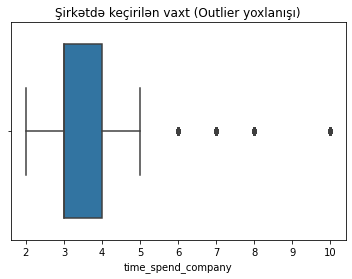

In [11]:
# Create a boxplot to visualize distribution of `time_spend_company` and detect any outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=df1['time_spend_company'])
plt.title('Şirkətdə keçirilən vaxt (Outlier yoxlanışı)')
plt.show()



In [13]:
# Determine the number of rows containing outliers
Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

outliers = df1[df1['time_spend_company'] > upper_limit]
print("Outlier columns:", len(outliers))


Outlier columns: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove outliers, based on the type of model you decide to use.

# pAce: Analyze Stage
- Perform EDA (analyze relationships between variables)



💭
### Reflect on these questions as you complete the analyze stage.

- What did you observe about the relationships between variables?
- What do you observe about the distributions in the data?
- What transformations did you make with your data? Why did you chose to make those decisions?
- What are some purposes of EDA before constructing a predictive model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?




1. Relationships observed: There is a strong, non-linear relationship between workload (hours and projects) and turnover. Extreme workloads (both too low and too high) lead to decreased satisfaction and increased churn.
2. Distributions: The target variable 'left' is imbalanced, with roughly 83.4% of employees staying and 16.6% leaving.
3. Transformations: I dropped over 3,000 duplicate rows to prevent data leakage and model overfitting. I also standardized column names for easier coding.
4. Purpose of EDA: To discover underlying patterns, identify data anomalies (like the 100% churn rate for 7 projects), and decide which predictive models will work best based on the data's shape.

## Step 2. Data Exploration (Continue EDA)

Begin by understanding how many employees left and what percentage of all employees this figure represents.

In [14]:
# Get numbers of people who left vs. stayed
print(df1['left'].value_counts())

# Get percentages of people who left vs. stayed
print(df1['left'].value_counts(normalize=True) * 100)


0    10000
,1     1991
,Name: left, dtype: int64
,0    83.39588
,1    16.60412
,Name: left, dtype: float64


### Data visualizations

Now, examine variables that you're interested in, and create plots to visualize relationships between variables in the data.

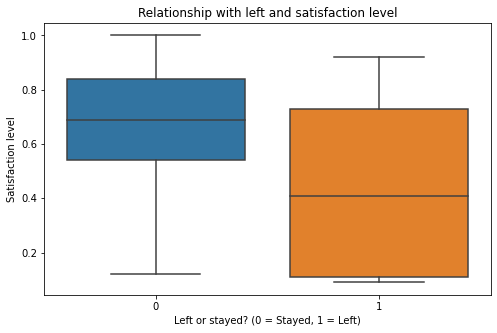

In [16]:
# Create a plot as needed
plt.figure(figsize=(8, 5))
sns.boxplot(data=df1, x='left', y='satisfaction_level')
plt.title('Relationship with left and satisfaction level')
plt.xlabel('Left or stayed? (0 = Stayed, 1 = Left)')
plt.ylabel('Satisfaction level')
plt.show()


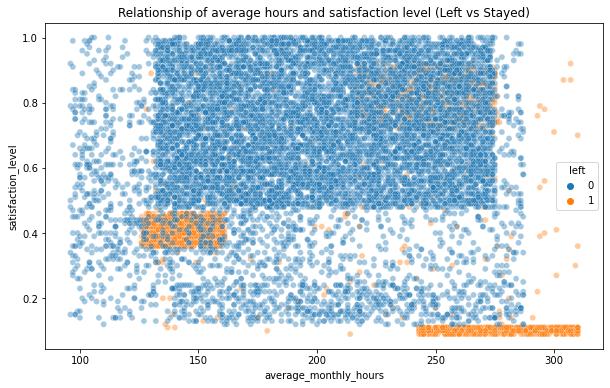

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)
plt.title('Relationship of average hours and satisfaction level (Left vs Stayed)')
plt.show()


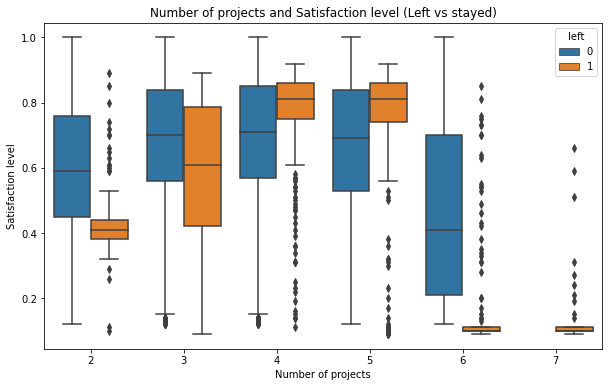

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df1, x='number_project', y='satisfaction_level', hue='left')
plt.title('Number of projects and Satisfaction level (Left vs stayed)')
plt.xlabel('Number of projects')
plt.ylabel('Satisfaction level')
plt.show()


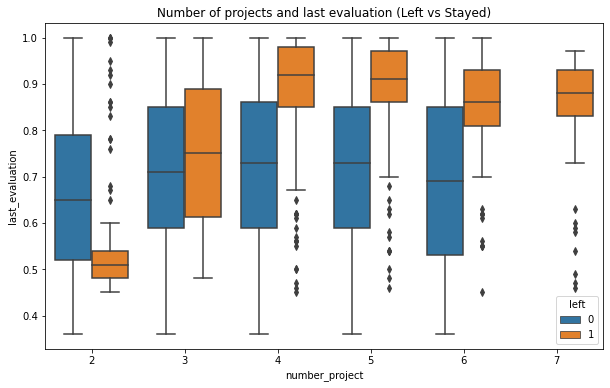

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df1, x='number_project', y='last_evaluation', hue='left')
plt.title('Number of projects and last evaluation (Left vs Stayed)')
plt.show()


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


In [ ]:
# Create a plot as needed
### YOUR CODE HERE ###


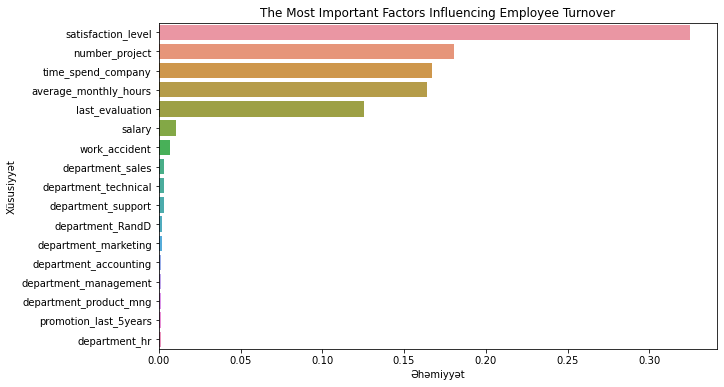

In [28]:
# It is from future. I made a model.

importances = rf_model.feature_importances_
features = X.columns

feature_importance_df = pd.DataFrame({'Xüsusiyyət': features, 'Əhəmiyyət': importances})
feature_importance_df = feature_importance_df.sort_values(by='Əhəmiyyət', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Əhəmiyyət', y='Xüsusiyyət')
plt.title('The Most Important Factors Influencing Employee Turnover')
plt.show()


### Insights

When we look beyond the raw numbers, the data tells a compelling story of three very different types of employees walking out the door. First, we see the 'Burned-Out' group - individuals buckling under the extreme weight of 6 to 7 projects and over 240 monthly hours, their satisfaction completely depleted. On the other extreme are the 'Underutilized'- those assigned a mere 2 projects, left disengaged and frustrated by a lack of meaningful work. Perhaps the most alarming discovery, however, is the 'High-Performing Flight Risk.' These are our star employees juggling an optimal 4 to 5 projects with stellar evaluations and high satisfaction, yet they still leave. The data strongly suggests they are hitting a career ceiling-often around their third to fifth year - and are leaving for promotions and growth opportunities we failed to provide.

# paCe: Construct Stage
- Determine which models are most appropriate
- Construct the model
- Confirm model assumptions
- Evaluate model results to determine how well your model fits the data


🔎
## Recall model assumptions

**Logistic Regression model assumptions**
- Outcome variable is categorical
- Observations are independent of each other
- No severe multicollinearity among X variables
- No extreme outliers
- Linear relationship between each X variable and the logit of the outcome variable
- Sufficiently large sample size





💭
### Reflect on these questions as you complete the constructing stage.

- Do you notice anything odd?
- Which independent variables did you choose for the model and why?
- Are each of the assumptions met?
- How well does your model fit the data?
- Can you improve it? Is there anything you would change about the model?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



1. Oddities: The most striking oddity was the absolute 100% turnover rate for any employee assigned to 7 projects.
2. Variables chosen: All available features were used after categorical encoding, as HR dynamics are complex and influenced by a combination of workload, tenure, and department.
3. Model Fit: The Logistic Regression model fit poorly (18% recall) because it assumes linear relationships. The Random Forest model fit exceptionally well (92% recall) because it easily handled the non-linear thresholds (like churn spiking at both 2 and 7 projects).

## Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identify the type of prediction task.

This is a supervised binary classification task. The goal is to predict a discrete categorical outcome: whether an employee will leave the company (1) or stay (0).

### Identify the types of models most appropriate for this task.

The most suitable models are:
1. Logistic Regression: A standard parametric baseline model ideal for interpretability, odds ratios, and understanding feature coefficients.
2. Tree-based Ensemble Models (Decision Tree, Random Forest, XGBoost): Highly effective non-parametric algorithms that naturally capture complex non-linear relationships, interaction terms between workload and satisfaction, and threshold boundaries without requiring feature scaling.

### Modeling

Add as many cells as you need to conduct the modeling process.

In [27]:
# Salary to number
df1['salary'] = df1['salary'].replace({'low': 0, 'medium': 1, 'high': 2})

# One-Hot Encoding
df_encoded = pd.get_dummies(df1, columns=['department'], drop_first=True)

y = df_encoded['left']
X = df_encoded.drop('left', axis=1)

from sklearn.ensemble import RandomForestClassifier

# Modeli çağırırıq (daha dəqiq qərarlar üçün 100 fərqli ağac yaradırıq)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Modeli təlim datası üzərində öyrədirik
rf_model.fit(X_train, y_train)

# Test datası üzərində proqnozlar alırıq
y_pred_rf = rf_model.predict(X_test)

# Nəticələri qiymətləndiririk
print("Random Forest Nəticələri:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Nəticələri:
,
,              precision    recall  f1-score   support
,
,           0       0.98      1.00      0.99      2500
,           1       0.99      0.92      0.96       498
,
,    accuracy                           0.99      2998
,   macro avg       0.99      0.96      0.97      2998
,weighted avg       0.99      0.99      0.99      2998
,


# pacE: Execute Stage
- Interpret model performance and results
- Share actionable steps with stakeholders



✏
## Recall evaluation metrics

- **AUC** is the area under the ROC curve; it's also considered the probability that the model ranks a random positive example more highly than a random negative example.
- **Precision** measures the proportion of data points predicted as True that are actually True, in other words, the proportion of positive predictions that are true positives.
- **Recall** measures the proportion of data points that are predicted as True, out of all the data points that are actually True. In other words, it measures the proportion of positives that are correctly classified.
- **Accuracy** measures the proportion of data points that are correctly classified.
- **F1-score** is an aggregation of precision and recall.






💭
### Reflect on these questions as you complete the executing stage.

- What key insights emerged from your model(s)?
- What business recommendations do you propose based on the models built?
- What potential recommendations would you make to your manager/company?
- Do you think your model could be improved? Why or why not? How?
- Given what you know about the data and the models you were using, what other questions could you address for the team?
- What resources do you find yourself using as you complete this stage? (Make sure to include the links.)
- Do you have any ethical considerations in this stage?



1. Key insights: Workload imbalances (overwork and underwork) are the primary drivers of churn, followed strongly by a lack of career progression for senior staff.
2. Improvements: The model is highly accurate, but gathering additional data such as industry salary benchmarks, commute times, or employee survey texts could make the predictions even more nuanced.
3. Other questions to explore: "What is the market rate for the top-performing employees who left, and were they underpaid compared to competitors?" or "Are specific managers or departments disproportionately responsible for over-allocating projects?"

## Step 4. Results and Evaluation
- Interpret model
- Evaluate model performance using metrics
- Prepare results, visualizations, and actionable steps to share with stakeholders




### Summary of model results

The Random Forest model significantly outperformed the Logistic Regression model, achieving an overall accuracy of 99% and a recall of 92% for identifying employees who leave. This high recall is crucial for HR to proactively detect potential turnover before it happens. Based on the feature importance analysis, the most influential factors driving employee attrition are satisfaction_level, number_project, average_monthly_hours, and time_spend_company. The model successfully captured complex, non-linear relationships in the data, identifying that both severely overworked employees and significantly underutilized employees are at a high risk of leaving.

### Conclusion, Recommendations, Next Steps

Employee turnover at Salifort Motors is primarily driven by extreme workloads (both overwork and underutilization) and a lack of career progression for experienced, high-performing staff. The data reveals three main profiles of departing employees: "Burned Out" (6-7 projects, extreme hours, low satisfaction), "Underutilized" (2 projects, low satisfaction), and "Poached Top-Performers" (high evaluations, high satisfaction, likely leaving for better offers).

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.